# Dependencies

In [36]:
import requests

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import xgboost as xgb

import yfinance as yf
from datetime import date

%matplotlib inline

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))

tqdm.pandas()

In [2]:
!where python

C:\Users\oluse\anaconda3\envs\udacitydlnndg\python.exe
C:\Users\oluse\AppData\Local\Microsoft\WindowsApps\python.exe


# Get Data

In [3]:
end_date = date.today().strftime("%Y-%m-%d")
print(end_date)
start_date = '2021-02-01'

df = yf.download('BNB-USD', start=start_date, end=end_date)

# Inspect the data
df.head()

2025-01-13


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BNB-USD,BNB-USD,BNB-USD,BNB-USD,BNB-USD
Date,,,,,
2021-02-01,51.607697,52.138683,43.524193,44.309074,1256933735
2021-02-02,51.056404,52.911865,49.387074,51.551884,1006694242
2021-02-03,52.242638,52.677433,49.955585,51.050102,714000888
2021-02-04,55.925125,57.070911,51.602642,52.242210,940905214
2021-02-05,67.845566,68.463959,56.010803,56.010803,1431595319


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2021-02-01 to 2025-01-12
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BNB-USD)   1442 non-null   float64
 1   (High, BNB-USD)    1442 non-null   float64
 2   (Low, BNB-USD)     1442 non-null   float64
 3   (Open, BNB-USD)    1442 non-null   float64
 4   (Volume, BNB-USD)  1442 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 67.6 KB


In [5]:
df.to_csv('../data/BNB-USD.csv', index=False) # save data

In [6]:
close_data = df.Close
# close_data
# close_data.tail()

In [7]:
close_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2021-02-01 to 2025-01-12
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BNB-USD  1442 non-null   float64
dtypes: float64(1)
memory usage: 22.5 KB


We rename the column and index for easy analysis

In [8]:
close_data.rename(columns={'BNB-USD': 'close'}, inplace=True)
close_data.index.name = 'date'


C:\Users\oluse\AppData\Local\Temp\ipykernel_20004\2357904293.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data.rename(columns={'BNB-USD': 'close'}, inplace=True)


# Visualization

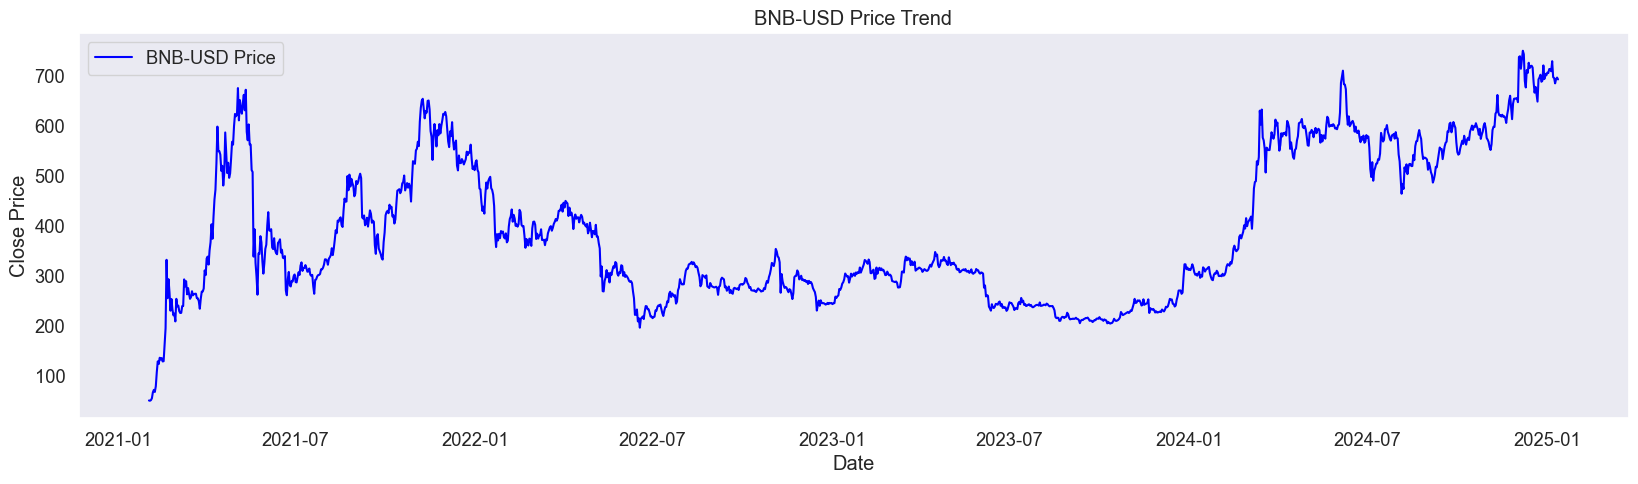

In [9]:
# a. Trend Plot
plt.figure(figsize=(20, 5))
plt.plot(close_data.index, close_data['close'], label='BNB-USD Price', color='blue')
plt.title('BNB-USD Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

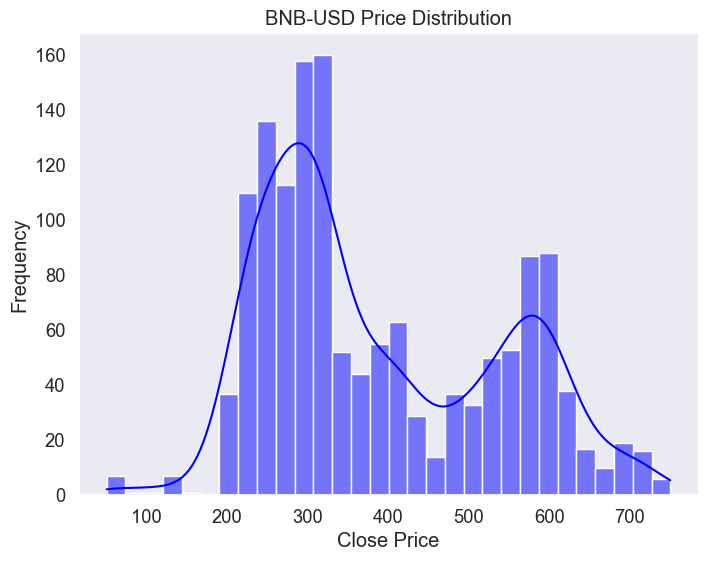

In [10]:
# b. Histogram of Prices
plt.figure(figsize=(8, 6))
sns.histplot(close_data['close'], bins=30, kde=True, color='blue')
plt.title('BNB-USD Price Distribution')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.grid()
plt.show()

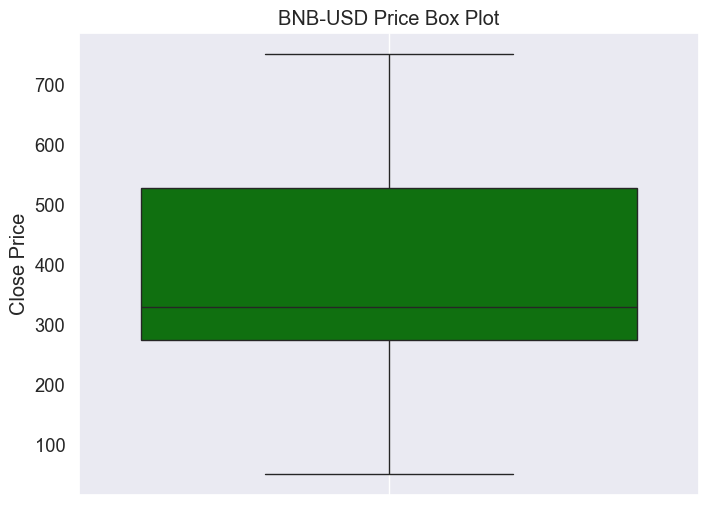

In [11]:
# c. Box Plot to Visualize Outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=close_data['close'], color='green')
plt.title('BNB-USD Price Box Plot')
plt.ylabel('Close Price')
plt.grid()
plt.show()

C:\Users\oluse\AppData\Local\Temp\ipykernel_20004\71740514.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data['rolling_mean'] = close_data['close'].rolling(window=30).mean()  # 30-day rolling mean
C:\Users\oluse\AppData\Local\Temp\ipykernel_20004\71740514.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data['rolling_std'] = close_data['close'].rolling(window=30).std()    # 30-day rolling std


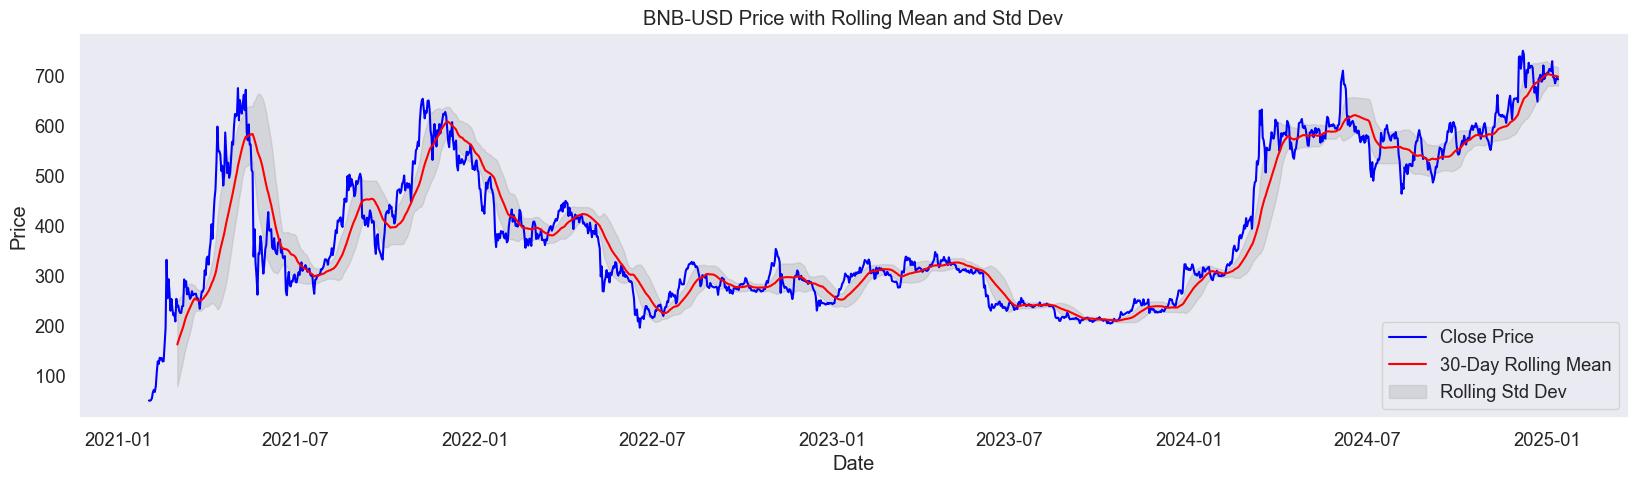

In [12]:
# d. Rolling Average and Volatility
close_data['rolling_mean'] = close_data['close'].rolling(window=30).mean()  # 30-day rolling mean
close_data['rolling_std'] = close_data['close'].rolling(window=30).std()    # 30-day rolling std

plt.figure(figsize=(20, 5))
plt.plot(close_data.index, close_data['close'], label='Close Price', color='blue')
plt.plot(close_data.index, close_data['rolling_mean'], label='30-Day Rolling Mean', color='red')
plt.fill_between(close_data.index,
                 close_data['rolling_mean'] - close_data['rolling_std'],
                 close_data['rolling_mean'] + close_data['rolling_std'],
                 color='gray', alpha=0.2, label='Rolling Std Dev')
plt.title('BNB-USD Price with Rolling Mean and Std Dev')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [13]:
close_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2021-02-01 to 2025-01-12
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   close         1442 non-null   float64
 1   rolling_mean  1413 non-null   float64
 2   rolling_std   1413 non-null   float64
dtypes: float64(3)
memory usage: 45.1 KB


# Feature Engineering

In [30]:
# Feature Engineering
def create_features(data):
    """
    Create lag and rolling features for the time series data.
    """
    data['lag_1'] = data['close'].shift(1)
    data['lag_2'] = data['close'].shift(2)
    data['lag_3'] = data['close'].shift(3)
    data['rolling_mean_3'] = data['close'].rolling(window=3).mean()
    data['rolling_std_3'] = data['close'].rolling(window=3).std()
    data['rolling_mean_7'] = data['close'].rolling(window=7).mean()
    return data

close_data = create_features(close_data)

# Drop rows with NaN values due to feature creation
close_data.dropna(inplace=True)

# Define features (X) and target (y)
X = close_data[['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_7']]
y = close_data['close'].values


# Train XGBoost model

In [34]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
print(X_train.head(1))

# Convert to DMatrix (XGBoost-specific format)
train_dmatrix = xgb.DMatrix(X_train, label=y_train)
test_dmatrix = xgb.DMatrix(X_test, label=y_test)

# XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 5,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'eval_metric': 'rmse'
}

Ticker           lag_1       lag_2       lag_3  rolling_mean_3  rolling_std_3  \
date                                                                            
2021-03-08  240.179214  226.666855  226.372559      235.721578        7.84193   

Ticker      rolling_mean_7  
date                        
2021-03-08      234.870895  


In [ ]:
# Train the model
xgb_model = xgb.train(
    params=params,
    dtrain=train_dmatrix,
    num_boost_round=100,
    evals=[(train_dmatrix, 'train'), (test_dmatrix, 'eval')],
    early_stopping_rounds=10
)

In [ ]:
# Make predictions
y_pred = xgb_model.predict(test_dmatrix)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

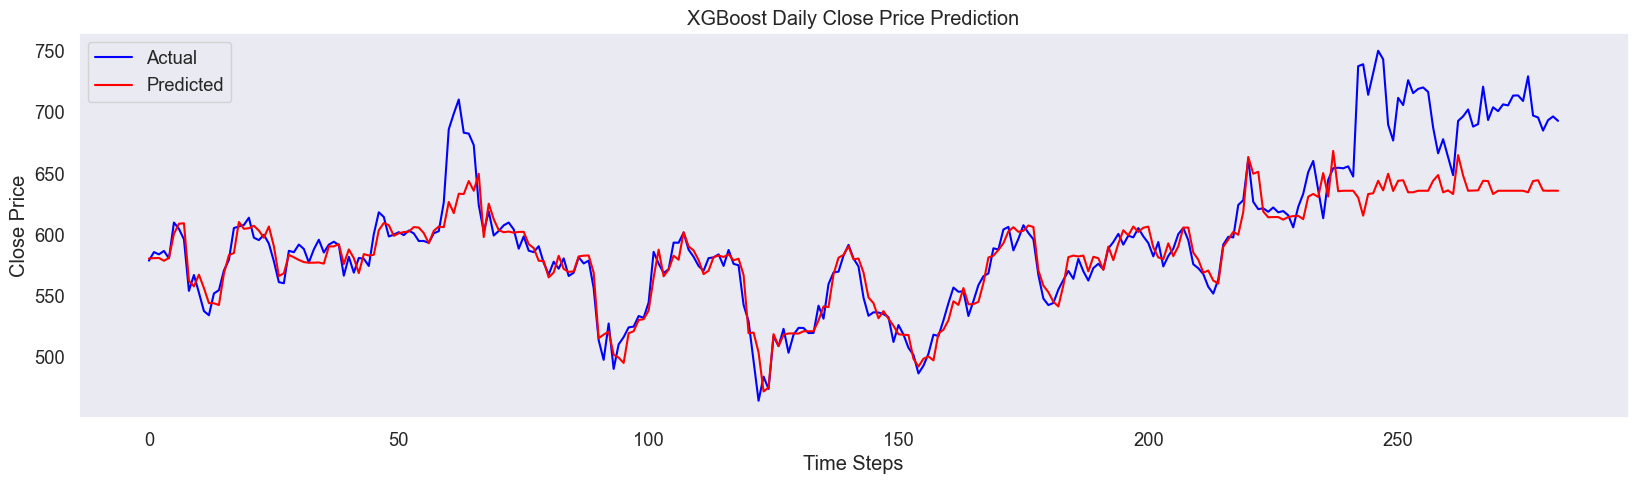

In [16]:
# Plot actual vs predicted
plt.figure(figsize=(20, 5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title('XGBoost Daily Close Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

# Hyperparameter tuning: XGBoost

In [17]:
# Define a function for hyperparameter tuning
def tune_xgboost(X_train, y_train):
    """
    Perform hyperparameter tuning for XGBoost using GridSearchCV.
    """
    # Create an XGBoost regressor
    xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

    # Define the parameter grid
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [50, 100, 200],
        'subsample': [0.8, 1],
        'colsample_bytree': [0.8, 1]
    }

    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=xgb_regressor,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Return the best model and parameters
    return grid_search.best_estimator_, grid_search.best_params_

In [18]:
# Perform hyperparameter tuning
best_model, best_params = tune_xgboost(X_train, y_train)

# Evaluate the best model on the test set
y_pred_best = best_model.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"Best Parameters: {best_params}")
print(f"RMSE with Best Parameters: {rmse_best}")

# Compare with the default model
default_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
default_model.fit(X_train, y_train)
y_pred_default = default_model.predict(X_test)
rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
print(f"RMSE with Default Parameters: {rmse_default}")

# Compare results
print(f"Improvement in RMSE: {rmse_default - rmse_best}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
RMSE with Best Parameters: 27.584027297968817
RMSE with Default Parameters: 30.77059755704968
Improvement in RMSE: 3.186570259080863


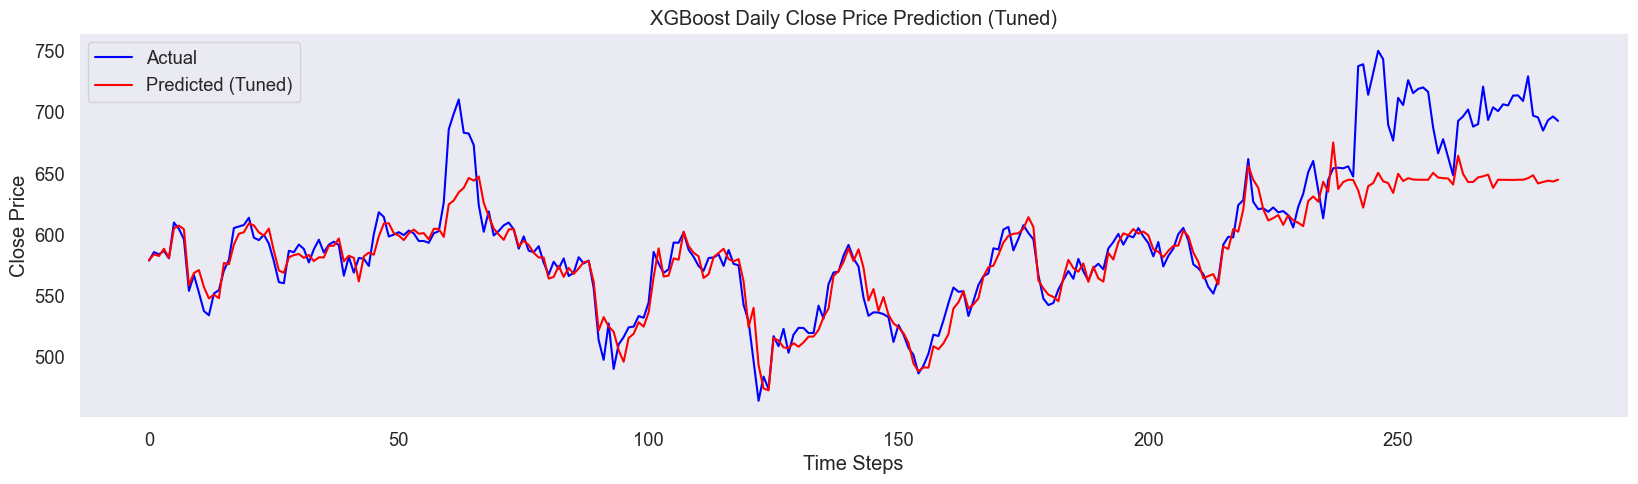

In [19]:
# Plot the predictions of the tuned model
plt.figure(figsize=(20, 5))
plt.plot(y_test, label='Actual', color='blue')
# plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred_best, label='Predicted (Tuned)', color='red')
plt.title('XGBoost Daily Close Price Prediction (Tuned)')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

# LSTM

In [20]:
# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape data for LSTM input (samples, time_steps, features)
X_scaled = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=False)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [21]:
# LSTM Model Definition
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.fc = nn.Linear(hidden_layer_size, output_size)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        predictions = self.fc(lstm_out[:, -1, :])  # Take the last time step output
        return predictions

In [22]:
# Hyperparameter Tuning (GridSearchCV won't work directly with PyTorch, we will manually try different parameters)
def train_lstm_model(hidden_layer_size, num_epochs=100, batch_size=32, learning_rate=0.001):
    model = LSTMModel(input_size=X_train.shape[2], hidden_layer_size=hidden_layer_size)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train the model
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        output = model(X_train_tensor)
        loss = loss_function(output.squeeze(), y_train_tensor)

        # Backward pass
        loss.backward()
        optimizer.step()

    # Evaluate the model
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).squeeze()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred.numpy()))
    return rmse

In [23]:
# Hyperparameter Tuning: Trying different configurations manually
hidden_layer_sizes = [100, 200, 300, 450, 600]
learning_rates = [ 0.01, 0.1, 0.25, 0.5, 0.65]
num_epochs = 50

best_rmse = float('inf')
best_params = {}

for hidden_layer_size in hidden_layer_sizes:
    for learning_rate in learning_rates:
        print(f"Training with hidden layer size: {hidden_layer_size}, learning rate: {learning_rate}")
        rmse = train_lstm_model(hidden_layer_size, num_epochs, learning_rate=learning_rate)
        print(f"RMSE: {rmse}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = {'hidden_layer_size': hidden_layer_size, 'learning_rate': learning_rate}

print(f"Best Hyperparameters: {best_params}")
print(f"Best RMSE: {best_rmse}")

Training with hidden layer size: 100, learning rate: 0.01
RMSE: 590.7727760315281
Training with hidden layer size: 100, learning rate: 0.1
RMSE: 259.01482183379846
Training with hidden layer size: 100, learning rate: 0.25
RMSE: 111.25412160973711
Training with hidden layer size: 100, learning rate: 0.5
RMSE: 62.87037071452919
Training with hidden layer size: 100, learning rate: 0.65
RMSE: 61.09423238615294
Training with hidden layer size: 200, learning rate: 0.01
RMSE: 589.6648296988596
Training with hidden layer size: 200, learning rate: 0.1
RMSE: 116.13625932020967
Training with hidden layer size: 200, learning rate: 0.25
RMSE: 84.36145279319516
Training with hidden layer size: 200, learning rate: 0.5
RMSE: 52.41811545505112
Training with hidden layer size: 200, learning rate: 0.65
RMSE: 66.05598859599166
Training with hidden layer size: 300, learning rate: 0.01
RMSE: 585.4585074919837
Training with hidden layer size: 300, learning rate: 0.1
RMSE: 91.31817052982633
Training with hidd

Final RMSE: 31.620477209963994


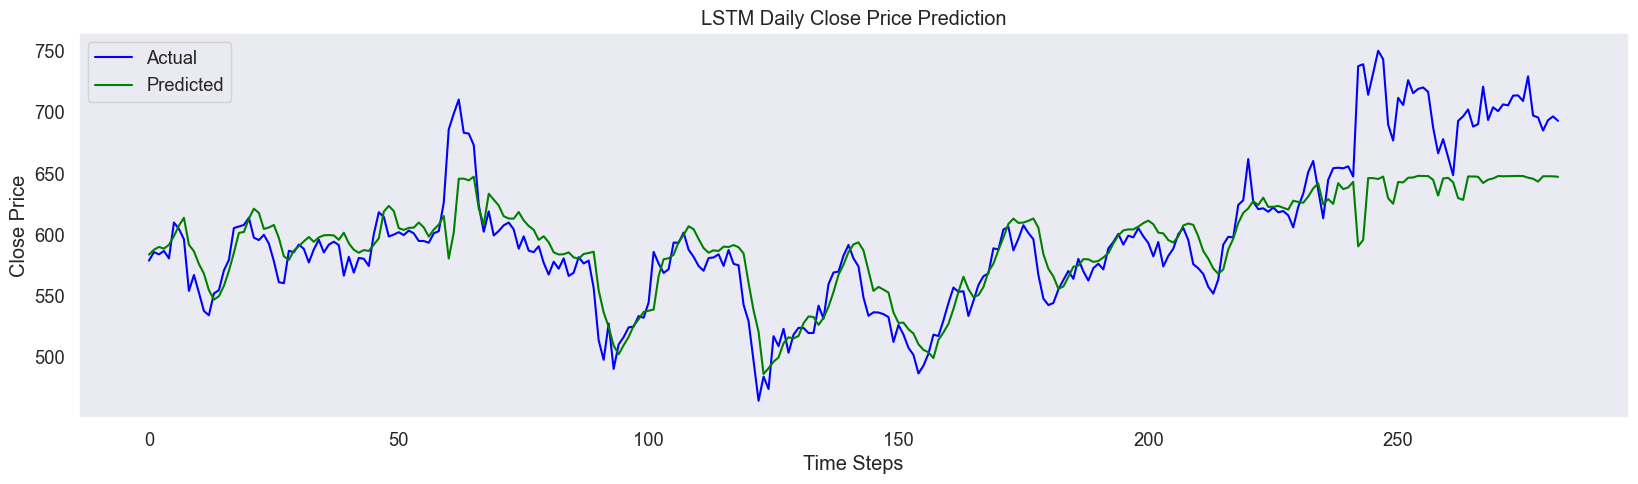

In [24]:
# Final Model with Best Hyperparameters
final_model = LSTMModel(input_size=X_train.shape[2], hidden_layer_size=best_params['hidden_layer_size'])
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['learning_rate'])

# Train the final model
final_model.train()
for epoch in range(num_epochs):
    final_model.train()
    optimizer.zero_grad()
    output = final_model(X_train_tensor)
    loss = loss_function(output.squeeze(), y_train_tensor)
    loss.backward()
    optimizer.step()

# Evaluate the final model
final_model.eval()
with torch.no_grad():
    y_pred_final = final_model(X_test_tensor).squeeze()

# Calculate RMSE for the final model
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final.numpy()))
print(f"Final RMSE: {final_rmse}")

# Plot actual vs predicted
plt.figure(figsize=(20, 5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_final.numpy(), label='Predicted', color='green')
plt.title('LSTM Daily Close Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

# Comparison plot

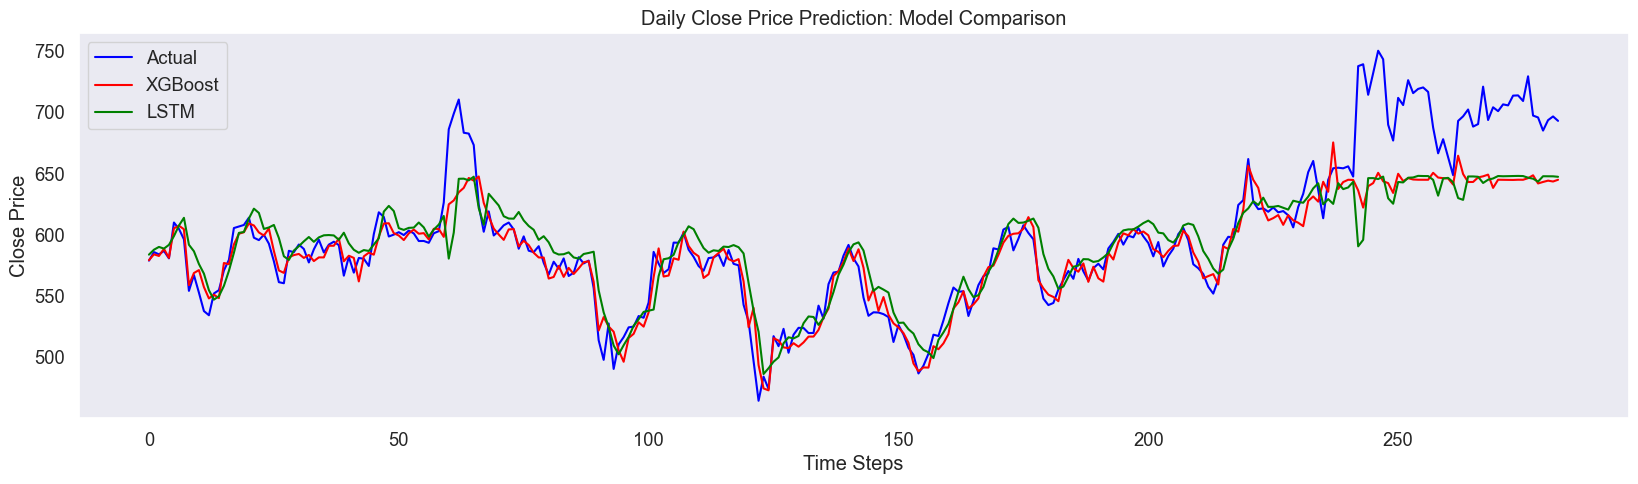

In [25]:
# Plot actual vs predicted
plt.figure(figsize=(20, 5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_best, label='XGBoost', color='red')
plt.plot(y_pred_final.numpy(), label='LSTM', color='green')
plt.title('Daily Close Price Prediction: Model Comparison')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

# Save Model

From the above and the RSME value, we see that the XGBoost model is the best. We save the model and deploy it later.

In [26]:
# Save the best XGBoost model to a file
best_model.save_model('../model/xgb_model.json')
print("Model saved as 'xgb_model.json'")


Model saved as 'xgb_model.json'


# Predict BNB Price

In [1]:
url = 'http://localhost:9100/bnbpriceprediction'

In [2]:
price_attributes = {
         "lag_1" : 320.1,
         "lag_2" : 315.5,
         "lag_3" : 310.2,
         "rolling_mean_3" : 315.27,
         "rolling_std_3" : 5.04,
        "rolling_mean_7" : 318.54,
     }

In [ ]:
features = ["lag_1", "lag_2", "lag_3", "rolling_mean_3", "rolling_std_3", "rolling_mean_7"]
X_new = np.array([[price_attributes[feature] for feature in features]])
X_new

In [75]:
model = '../model/xgb_model.json'
xgb_model = xgb.XGBRegressor()
xgb_model.load_model(model)
print("Model loaded successfully")

Model loaded successfully


In [76]:
# Predict using the loaded model
new_prediction = xgb_model.predict(X_new)
print(new_prediction[0])

313.95383


In [7]:
import requests
response = requests.post(url, json=price_attributes).json()
print(response)


{'new_prediction': 313.9538269042969}


In [79]:
# import numpy as np
# import xgboost as xgb
#
# # User input
# price_attributes = {
#     "lag_1": 320.1,
#     "lag_2": 315.5,
#     "lag_3": 310.2,
#     "rolling_mean_3": 315.27,
#     "rolling_std_3": 5.04,
#     "rolling_mean_7": 318.54,
# }
#
# # Step 1: Ensure features are in the correct order
# # This must match the training data feature order
# features = ["lag_1", "lag_2", "lag_3", "rolling_mean_3", "rolling_std_3", "rolling_mean_7"]
#
# # Convert the dictionary values into a list in the correct order
# X_new = np.array([[price_attributes[feature] for feature in features]])
#
# # Step 2: Load the trained XGBoost model
# model = '../model/xgb_model.json'
# xgb_model = xgb.XGBRegressor()
# xgb_model.load_model(model)
# print("Model loaded successfully")
#
# # Step 3: Predict the target value
# # new_dmatrix = xgb.DMatrix(X_new)
# predicted_price = xgb_model.predict(X_new)
#
# # Step 4: Output the result
# print(f"Predicted price: {predicted_price[0]:.2f}")
